<a href="https://colab.research.google.com/github/prabh2012/My-Projects/blob/main/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [ ]:
df = pd.read_csv("/content/Dataset of Diabetes .csv")
df.head()

,ID,No_Pation,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,CLASS
0,502,17975,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
1,735,34221,M,26,4.5,62,4.9,3.7,1.4,1.1,2.1,0.6,23.0,N
2,420,47975,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
3,680,87656,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
4,504,34223,M,33,7.1,46,4.9,4.9,1.0,0.8,2.0,0.4,21.0,N


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ID         1000 non-null   int64  
 1   No_Pation  1000 non-null   int64  
 2   Gender     1000 non-null   object 
 3   AGE        1000 non-null   int64  
 4   Urea       1000 non-null   float64
 5   Cr         1000 non-null   int64  
 6   HbA1c      1000 non-null   float64
 7   Chol       1000 non-null   float64
 8   TG         1000 non-null   float64
 9   HDL        1000 non-null   float64
 10  LDL        1000 non-null   float64
 11  VLDL       1000 non-null   float64
 12  BMI        1000 non-null   float64
 13  CLASS      1000 non-null   object 
dtypes: float64(8), int64(4), object(2)
memory usage: 109.5+ KB


The given dataset is a real-world healthcare dataset related to diabetes patients.
It contains clinical attributes such as Age, Gender, BMI, HbA1c, cholesterol levels, urea, creatinine, and lipid profile values.
This dataset is suitable for healthcare analytics as it helps analyze patterns and risk factors related to diabetes.

In [ ]:
#Check Missing Values
df.isnull().sum()

,0
ID,0
No_Pation,0
Gender,0
AGE,0
Urea,0
Cr,0
HbA1c,0
Chol,0
TG,0
HDL,0


Observation :

There are no missing values in the dataset.

In [ ]:
#Mean, Median, Mode, Standard Deviation
# Select required numerical columns
stats_df = df[['AGE', 'BMI', 'HbA1c', 'Chol']]

# Mean
mean_values = stats_df.mean()
print("MEAN:\n", mean_values, "\n")

# Median
median_values = stats_df.median()
print("MEDIAN:\n", median_values, "\n")

# Mode
mode_values = stats_df.mode()
print("MODE:\n", mode_values, "\n")

# Standard Deviation
std_values = stats_df.std()
print("STANDARD DEVIATION:\n", std_values)

MEAN:
 AGE      53.52800
BMI      29.57802
HbA1c     8.28116
Chol      4.86282
dtype: float64 

MEDIAN:
 AGE      55.0
BMI      30.0
HbA1c     8.0
Chol      4.8
dtype: float64 

MODE:
    AGE   BMI  HbA1c  Chol
0   55  30.0    8.0   4.4 

STANDARD DEVIATION:
 AGE      8.799241
BMI      4.962388
HbA1c    2.534003
Chol     1.301738
dtype: float64


In [ ]:
#Table Format
summary_stats = pd.DataFrame({
    'Mean': stats_df.mean(),
    'Median': stats_df.median(),
    'Mode': stats_df.mode().iloc[0],
    'Standard Deviation': stats_df.std()
})

summary_stats

,Mean,Median,Mode,Standard Deviation
AGE,53.52800,55.0,55.0,8.799241
BMI,29.57802,30.0,30.0,4.962388
HbA1c,8.28116,8.0,8.0,2.534003
Chol,4.86282,4.8,4.4,1.301738


The mean represents the average value of the health parameters.

The median shows the central value, which is less affected by extreme values.

The mode indicates the most frequently occurring value.

The standard deviation reflects the variability in patient health conditions.

HbA1c and BMI show noticeable variation, indicating differences in diabetes severity among patients.

In [ ]:
#OUTLIER DETECTION (IQR METHOD)
#Step 1: IQR Function
def detect_outliers_iqr(column):
    Q1 = column.quantile(0.25)
    Q3 = column.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = column[(column < lower_bound) | (column > upper_bound)]
    return outliers

In [ ]:
#Step 2: Apply Outlier Detection
outliers_age = detect_outliers_iqr(df['AGE'])
outliers_bmi = detect_outliers_iqr(df['BMI'])
outliers_hba1c = detect_outliers_iqr(df['HbA1c'])
outliers_chol = detect_outliers_iqr(df['Chol'])

print("AGE Outliers Count:", len(outliers_age))
print("BMI Outliers Count:", len(outliers_bmi))
print("HbA1c Outliers Count:", len(outliers_hba1c))
print("Cholesterol Outliers Count:", len(outliers_chol))

AGE Outliers Count: 98
BMI Outliers Count: 3
HbA1c Outliers Count: 6
Cholesterol Outliers Count: 27


Outliers were detected using the Interquartile Range (IQR) method.
Values lying below Q1 − 1.5×IQR or above Q3 + 1.5×IQR were considered outliers.
The presence of outliers indicates extreme health conditions in some patients, which may affect statistical analysis.

In [ ]:
#VISUAL OUTLIER DETECTION (BOXPLOTS)
plt.figure(figsize=(12,6))

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

Text(0.5, 1.0, 'Boxplot of Age')

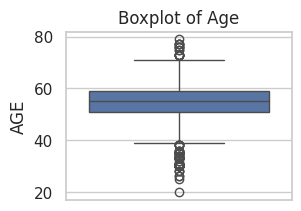

In [ ]:
#FOR AGE
plt.subplot(2,2,1)
sns.boxplot(y=df['AGE'])
plt.title("Boxplot of Age")

Text(0.5, 1.0, 'Boxplot of BMI')

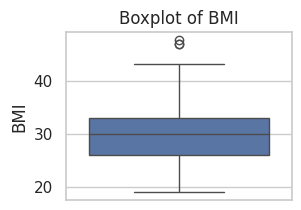

In [ ]:
#FOR BMI
plt.subplot(2,2,2)
sns.boxplot(y=df['BMI'])
plt.title("Boxplot of BMI")


Text(0.5, 1.0, 'Boxplot of HbA1c')

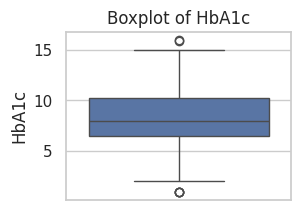

In [ ]:
#FOR HbA1c
plt.subplot(2,2,3)
sns.boxplot(y=df['HbA1c'])
plt.title("Boxplot of HbA1c")

Text(0.5, 1.0, 'Boxplot of Cholesterol')

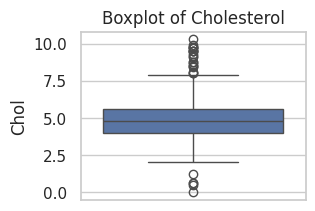

In [ ]:
#FOR CHOLESTEROL
plt.subplot(2,2,4)
sns.boxplot(y=df['Chol'])
plt.title("Boxplot of Cholesterol")

The boxplots reveal the presence of outliers in BMI, HbA1c, and cholesterol levels.
These outliers represent patients with unusually high or low medical readings, which may require special attention in healthcare analysis.

Univariate Analysis on Numerical Variables.
Selected Variables:

AGE,
BMI

Univariate analysis studies one variable at a time to understand its distribution.

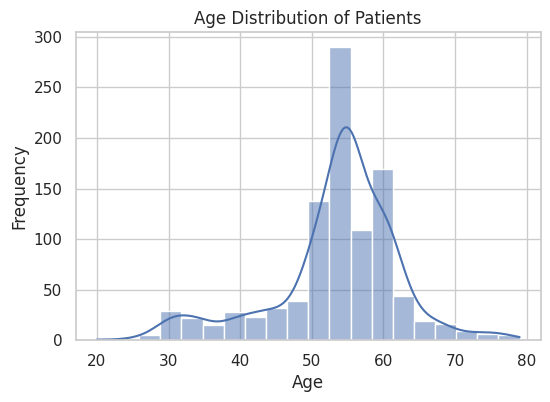

In [ ]:
#FOR AGE
plt.figure(figsize=(6,4))
sns.histplot(df['AGE'], bins=20, kde=True)
plt.title("Age Distribution of Patients")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

The age distribution shows that a majority of patients are middle-aged.

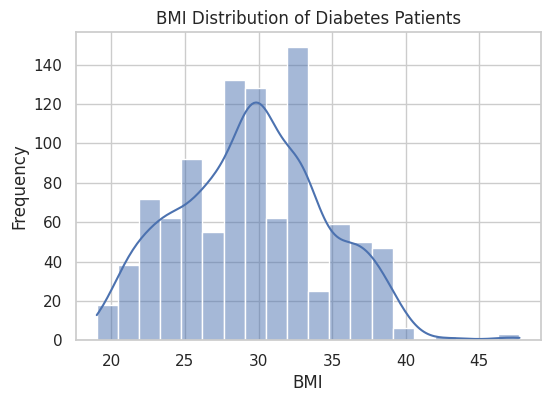

In [ ]:
#FOR BMI
plt.figure(figsize=(6,4))
sns.histplot(df['BMI'], bins=20, kde=True)
plt.title("BMI Distribution of Diabetes Patients")
plt.xlabel("BMI")
plt.ylabel("Frequency")
plt.show()

The BMI distribution indicates that many patients fall in the overweight and obese categories, which is a major risk factor for diabetes.

Bivariate Analysis
(One Categorical + One Numerical Variable)

Selected Variables:

Categorical: Gender

Numerical: HbA1c

Bivariate analysis is used to study the relationship between a categorical and a numerical variable.
A bar chart is an effective graphical representation to compare the average numerical values across different categories.

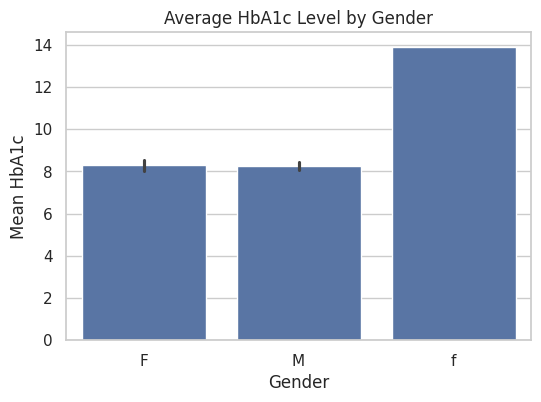

In [ ]:
#Gender vs HbA1c (Barplot)
plt.figure(figsize=(6,4))
sns.barplot(x='Gender', y='HbA1c', data=df, estimator=np.mean)
plt.title("Average HbA1c Level by Gender")
plt.xlabel("Gender")
plt.ylabel("Mean HbA1c")
plt.show()

The bar chart represents the average HbA1c levels for male and female patients.
Both genders show elevated HbA1c values, indicating the presence of diabetes.

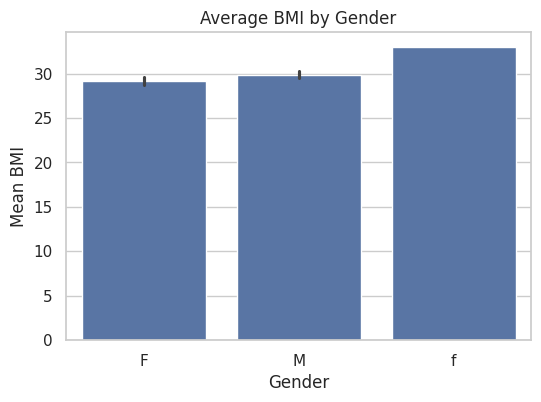

In [ ]:
#Gender vs BMI (Bar Chart – Mean BMI)
plt.figure(figsize=(6,4))
sns.barplot(
    x='Gender',
    y='BMI',
    data=df,
    estimator=np.mean
)
plt.title("Average BMI by Gender")
plt.xlabel("Gender")
plt.ylabel("Mean BMI")
plt.show()

The bar chart illustrates the average BMI values across different gender categories present in the dataset.
All gender groups show relatively high BMI values, indicating overweight or obesity, which is a major risk factor for diabetes.
The comparison suggests that elevated BMI is common across genders, with minor variations.

DASHBOARD: Multiple Visualizations in One View
Visuals included:

Age Distribution

BMI Distribution

Average HbA1c by Gender

Cholesterol Distribution

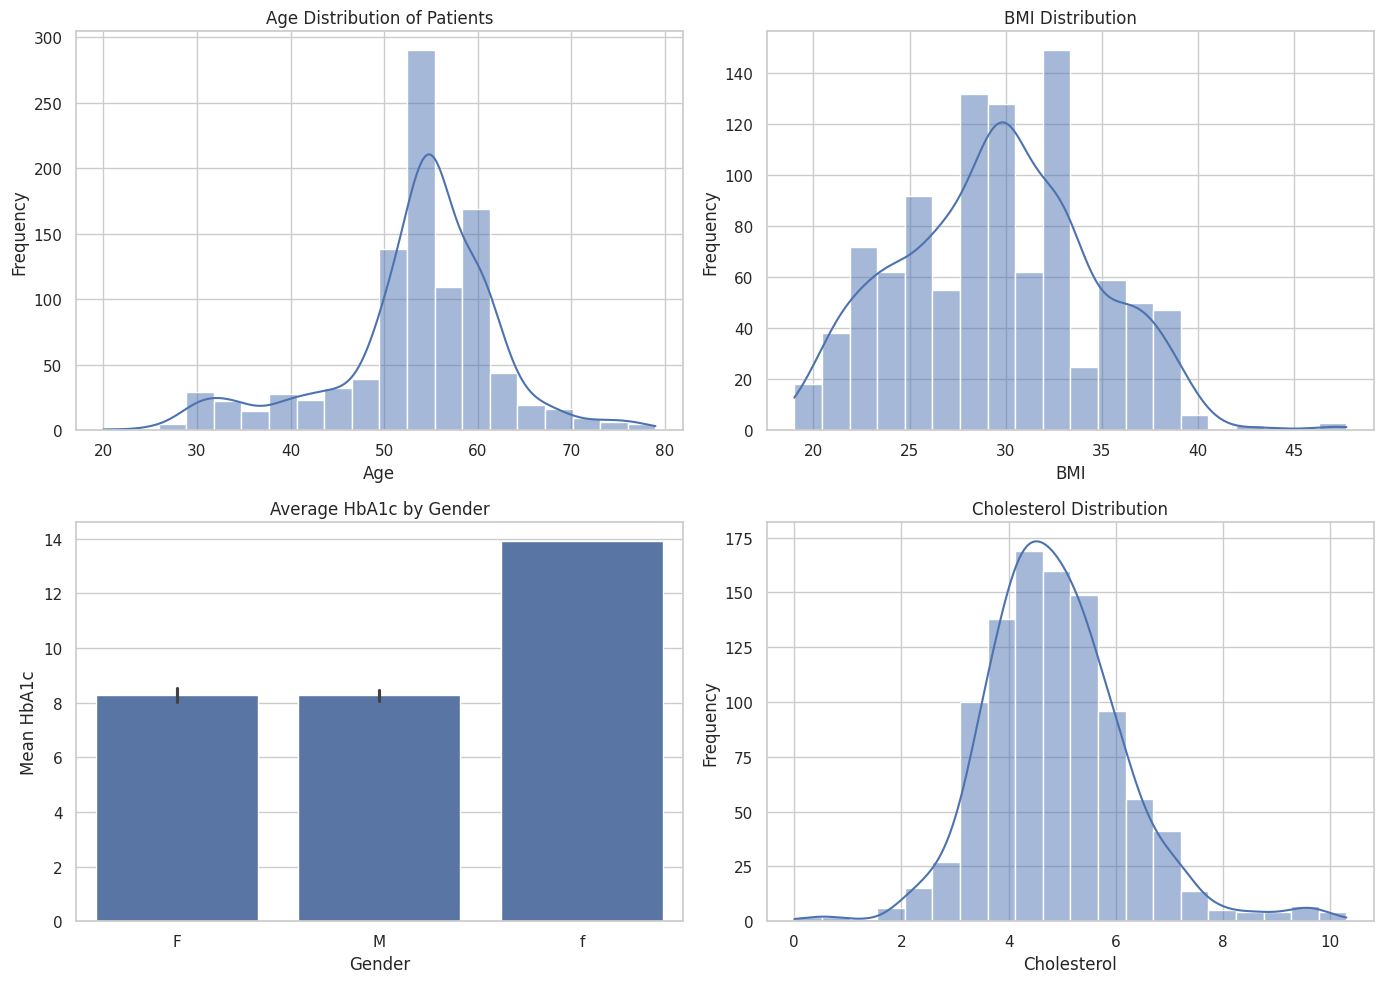

In [ ]:
#DASHBOARD CREATION
plt.figure(figsize=(14,10))

# 1. Age Distribution
plt.subplot(2,2,1)
sns.histplot(df['AGE'], bins=20, kde=True)
plt.title("Age Distribution of Patients")
plt.xlabel("Age")
plt.ylabel("Frequency")

# 2. BMI Distribution
plt.subplot(2,2,2)
sns.histplot(df['BMI'], bins=20, kde=True)
plt.title("BMI Distribution")
plt.xlabel("BMI")
plt.ylabel("Frequency")

# 3. Average HbA1c by Gender
plt.subplot(2,2,3)
sns.barplot(x='Gender', y='HbA1c', data=df, estimator=np.mean)
plt.title("Average HbA1c by Gender")
plt.xlabel("Gender")
plt.ylabel("Mean HbA1c")

# 4. Cholesterol Distribution
plt.subplot(2,2,4)
sns.histplot(df['Chol'], bins=20, kde=True)
plt.title("Cholesterol Distribution")
plt.xlabel("Cholesterol")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

Insight 1:

Most patients belong to the middle-age group, indicating higher diabetes prevalence in this age range.

Insight 2:

BMI distribution shows that a large number of patients are overweight or obese, which is a major risk factor for diabetes.

Insight 3:

HbA1c levels remain high across all gender categories, indicating poor glycemic control among patients.

The overall analysis of the diabetes dataset reveals that factors such as age, BMI, HbA1c, and cholesterol levels play a crucial role in understanding diabetes severity.
The presence of high BMI and elevated HbA1c values across different gender groups indicates widespread metabolic risk among patients.
The visual dashboard effectively integrates multiple health indicators, enabling quick identification of trends and supporting data-driven decision-making in healthcare management.